In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier as xgb

from sklearn.metrics import accuracy_score,roc_curve, auc, confusion_matrix, recall_score, precision_score,f1_score,classification_report

import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression



test_data_path = "/kaggle/input/ultimate-customer-churn-prediction-challenge/test.csv"
train_data_path = "/kaggle/input/ultimate-customer-churn-prediction-challenge/train.csv"

train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

In [2]:
test_data_path = "/kaggle/input/ultimate-customer-churn-prediction-challenge/test.csv"
train_data_path = "/kaggle/input/ultimate-customer-churn-prediction-challenge/train.csv"

train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

In [3]:
encoder = LabelEncoder()

test_data_le = test_data.copy()

test_data_le['Gender'] = encoder.fit_transform(test_data_le['Gender'])

test_data_le['Location'] = encoder.fit_transform(test_data_le['Location'])

test_data_le['Subscription_Type'] = encoder.fit_transform(test_data_le['Subscription_Type'])

test_data_le['Last_Interaction_Type'] = encoder.fit_transform(test_data_le['Last_Interaction_Type'])

test_data_le.drop(columns={'Customer_ID'},inplace=True)

print(len(test_data))
test_data_le.head()

2000


,Age,Gender,Location,Subscription_Type,Account_Age_Months,Monthly_Spending,Total_Usage_Hours,Support_Calls,Late_Payments,Streaming_Usage,Discount_Used,Satisfaction_Score,Last_Interaction_Type,Complaint_Tickets,Promo_Opted_In
0,61,0,3,2,26,101.91,37,7,0,73,66,9,0,2,0
1,33,1,2,0,44,33.05,160,9,1,13,8,6,0,4,0
2,22,0,0,2,3,36.67,240,6,4,43,65,2,1,0,0
3,22,1,4,2,45,172.92,172,7,1,75,69,8,0,0,0
4,52,1,2,2,47,30.98,136,8,4,58,7,8,0,3,1


In [4]:
encoder = LabelEncoder()

train_data_le = train_data.copy()

train_data_le['Gender'] = encoder.fit_transform(train_data_le['Gender'])

train_data_le['Location'] = encoder.fit_transform(train_data_le['Location'])

train_data_le['Subscription_Type'] = encoder.fit_transform(train_data_le['Subscription_Type'])

train_data_le['Last_Interaction_Type'] = encoder.fit_transform(train_data_le['Last_Interaction_Type'])

train_data_le.drop(columns={'Customer_ID'},inplace=True)

train_data_le.head()

,Age,Gender,Location,Subscription_Type,Account_Age_Months,Monthly_Spending,Total_Usage_Hours,Support_Calls,Late_Payments,Streaming_Usage,Discount_Used,Satisfaction_Score,Last_Interaction_Type,Complaint_Tickets,Promo_Opted_In,Churn
0,19,1,2,0,50,152.44,416,5,2,61,76,3,1,0,1,1
1,41,1,0,2,14,113.34,36,5,1,17,90,5,0,3,0,0
2,44,0,1,0,2,168.39,207,3,1,85,12,6,1,3,0,1
3,21,1,1,0,55,197.12,379,4,3,54,32,4,2,3,1,0
4,65,1,3,2,12,84.46,475,5,4,82,62,1,1,0,0,1


In [5]:
train_data_le.drop(columns={'Age', 'Gender', 'Location', 'Subscription_Type',
       'Account_Age_Months',
       'Streaming_Usage', 'Discount_Used',
       'Satisfaction_Score',
       'Promo_Opted_In'},inplace=True)
test_data_le.head()

,Age,Gender,Location,Subscription_Type,Account_Age_Months,Monthly_Spending,Total_Usage_Hours,Support_Calls,Late_Payments,Streaming_Usage,Discount_Used,Satisfaction_Score,Last_Interaction_Type,Complaint_Tickets,Promo_Opted_In
0,61,0,3,2,26,101.91,37,7,0,73,66,9,0,2,0
1,33,1,2,0,44,33.05,160,9,1,13,8,6,0,4,0
2,22,0,0,2,3,36.67,240,6,4,43,65,2,1,0,0
3,22,1,4,2,45,172.92,172,7,1,75,69,8,0,0,0
4,52,1,2,2,47,30.98,136,8,4,58,7,8,0,3,1


In [6]:
test_data_le.drop(columns={'Age', 'Gender', 'Location', 'Subscription_Type',
       'Account_Age_Months',
       'Streaming_Usage', 'Discount_Used',
       'Satisfaction_Score',
       'Promo_Opted_In'},inplace=True)
test_data_le.head()

,Monthly_Spending,Total_Usage_Hours,Support_Calls,Late_Payments,Last_Interaction_Type,Complaint_Tickets
0,101.91,37,7,0,0,2
1,33.05,160,9,1,0,4
2,36.67,240,6,4,1,0
3,172.92,172,7,1,0,0
4,30.98,136,8,4,0,3


In [7]:
train_data_dummified = pd.get_dummies(train_data_le,dtype=float)

#train_data_dummified.drop(columns={'Customer_ID'},inplace=True)

train_data_dummified.head()

,Monthly_Spending,Total_Usage_Hours,Support_Calls,Late_Payments,Last_Interaction_Type,Complaint_Tickets,Churn
0,152.44,416,5,2,1,0,1
1,113.34,36,5,1,0,3,0
2,168.39,207,3,1,1,3,1
3,197.12,379,4,3,2,3,0
4,84.46,475,5,4,1,0,1


In [8]:
test_data_dummified = pd.get_dummies(train_data_le,dtype=float)

#train_data_dummified.drop(columns={'Customer_ID'},inplace=True)

test_data_dummified.head()

,Monthly_Spending,Total_Usage_Hours,Support_Calls,Late_Payments,Last_Interaction_Type,Complaint_Tickets,Churn
0,152.44,416,5,2,1,0,1
1,113.34,36,5,1,0,3,0
2,168.39,207,3,1,1,3,1
3,197.12,379,4,3,2,3,0
4,84.46,475,5,4,1,0,1


In [9]:
train_data_dummified.fillna(0,inplace=True)

X = train_data_dummified.drop(columns={'Churn'})

y = train_data_dummified[['Churn']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = True)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# XGBoostClassifier model
model = xgb(random_state=42)

# Training the model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

The model accuracy is 0.6333333333333333
recall:0.1436241610738255
precision:0.30659025787965616
F1 Score : 0.1956124314442413


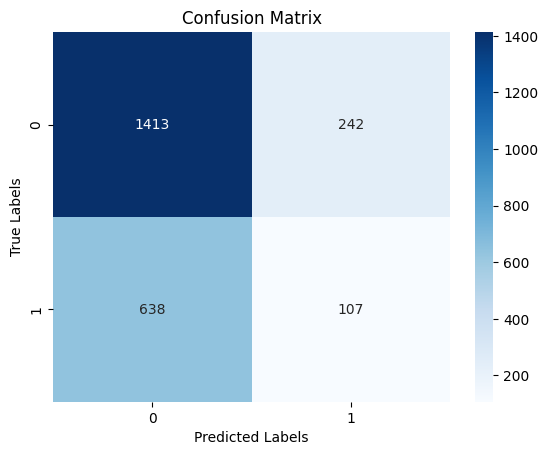

In [10]:
# Predicting test dataset values with the model
y_pred = model.predict(X_test)

# Accuracy check of the model prediction
print("The model accuracy is", accuracy_score(y_test,y_pred))

print("recall:" + str(recall_score(y_test, y_pred)))
print("precision:" + str(precision_score(y_test, y_pred)))
print(f"F1 Score : {f1_score(y_test, y_pred)}")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

The model accuracy is 0.58625
recall:0.23624161073825503
precision:0.29333333333333333
F1 Score : 0.26171003717472124


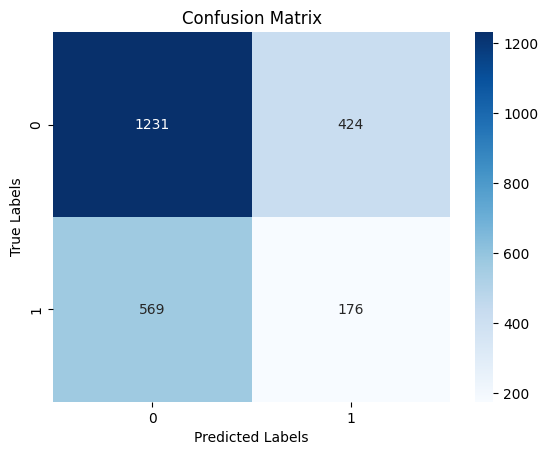

In [11]:
### Balance and Re-Model XGB

# SMOTE to balance dataset
smote=SMOTE(sampling_strategy='minority') 
X_train_smote, y_train_smote = smote.fit_resample(X, y)

# XGBoostClassifier model
model = xgb(random_state=42)

# Training the model
model.fit(X_train_smote, y_train_smote)

# Predicting test dataset values with the model
y_pred = model.predict(X_test)

# Accuracy check of the model prediction
print("The model accuracy is", accuracy_score(y_test,y_pred))
print("recall:" + str(recall_score(y_test, y_pred)))
print("precision:" + str(precision_score(y_test, y_pred)))
print(f"F1 Score : {f1_score(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

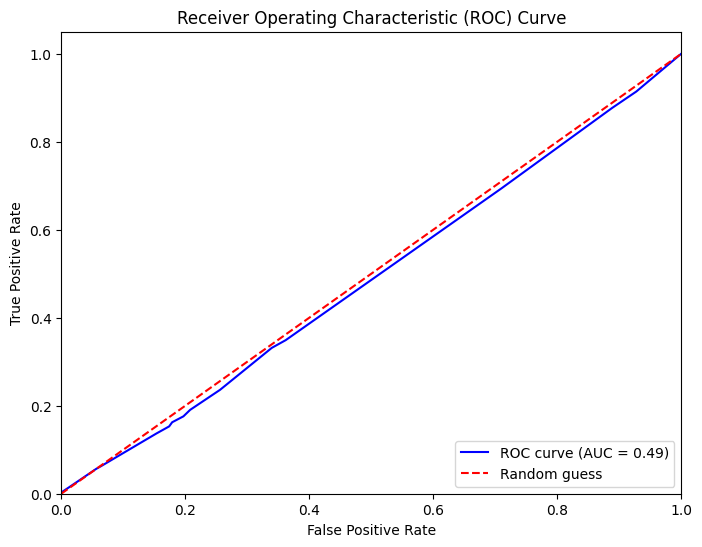

In [12]:
# Make predictions on the test set with predict_proba
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the area under the ROC curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [13]:
print(f'Classification Report: \n{classification_report(y_test, y_pred)}')


Classification Report: 
              precision    recall  f1-score   support

           0       0.68      0.74      0.71      1655
           1       0.29      0.24      0.26       745

    accuracy                           0.59      2400
   macro avg       0.49      0.49      0.49      2400
weighted avg       0.56      0.59      0.57      2400



In [14]:
### Undersample to minority class

undersample = NearMiss(version=2, n_neighbors=2)
# transform the dataset
X_train_undersample, y_train_undersample = undersample.fit_resample(X_train, y_train)

y_train_undersample['Churn'].value_counts()

Churn
0    1760
1    1760
Name: count, dtype: int64

The model accuracy is 0.4625
recall:0.6134228187919463
precision:0.3132282385195339
F1 Score : 0.4147005444646098


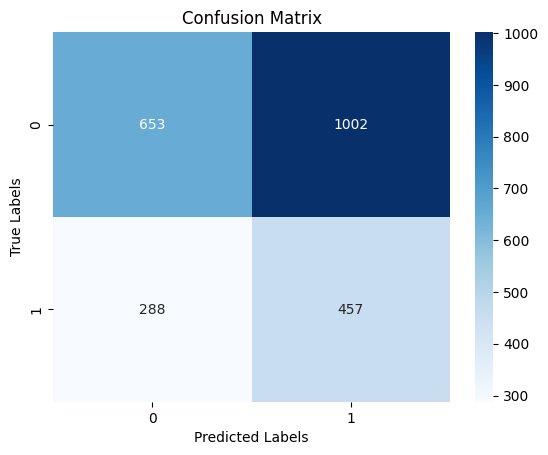

In [15]:
# XGBoostClassifier model
model = xgb(random_state=42)

# Training the model
model.fit(X_train_undersample, y_train_undersample)

# Predicting test dataset values with the model
y_pred = model.predict(X_test)

# Accuracy check of the model prediction
print("The model accuracy is", accuracy_score(y_test,y_pred))
print("recall:" + str(recall_score(y_test, y_pred)))
print("precision:" + str(precision_score(y_test, y_pred)))
print(f"F1 Score : {f1_score(y_test, y_pred)}")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

The model accuracy is 0.4625
recall:0.6134228187919463
precision:0.3132282385195339
F1 Score : 0.4147005444646098


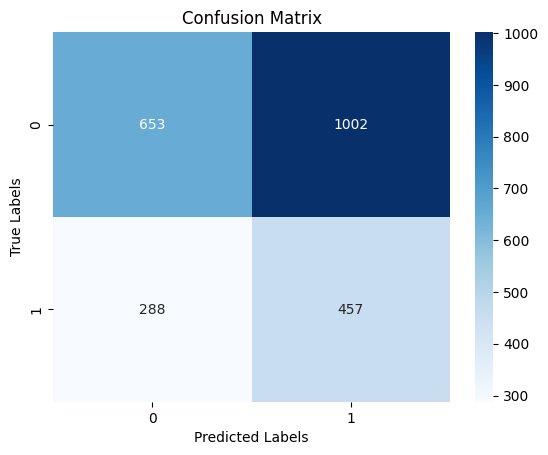

In [16]:
# XGBoostClassifier model
model = xgb(random_state=42)

# Training the model
model.fit(X_train_undersample, y_train_undersample)

# Predicting test dataset values with the model
y_pred = model.predict(X_test)

# Accuracy check of the model prediction
print("The model accuracy is", accuracy_score(y_test,y_pred))
print("recall:" + str(recall_score(y_test, y_pred)))
print("precision:" + str(precision_score(y_test, y_pred)))
print(f"F1 Score : {f1_score(y_test, y_pred)}")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [17]:
from sklearn.metrics import fbeta_score

# y_true = actual labels
# y_pred = predicted labels (not probabilities)
f2 = fbeta_score(y_test, y_pred, beta=2)
print("F2 Score:", f2)

F2 Score: 0.5147555755800856


In [18]:

sc = StandardScaler()
sc.fit(X_train)  # Fit on training data
test_data_le_standardized = sc.transform(test_data_le)

# Prediction
y_pred = model.predict(test_data_le_standardized)
y_pred_proba = model.predict_proba(test_data_le_standardized)[:, 1]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [19]:
final_output_data = test_data[['Customer_ID']]
final_output_data['prob'] = y_pred_proba
# final_output_data['click?'] = y_pred

final_output_data.head()

<ipython-input-19-cd7d79f962fb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_output_data['prob'] = y_pred_proba


,Customer_ID,prob
0,9001,0.999615
1,9002,0.999628
2,9003,0.998479
3,9004,0.999858
4,9005,0.999729


In [20]:
final_output_data.to_csv('/kaggle/working/submission.csv', index=False)